Trabalho para integração entre disciplinas<br>
Projeto Integrado: “Do Dado ao Insight”<br>
Disciplinas:  Big Data, Computação na Nuvem, Análise Computacional e
Qualitativa de Dados<br>
Aluna: Marja Tanita de Oliveira Ramos Gringel<br>
Professores: Andrea Costa do Nascimento e Manuel Martins<br>

🌳 README — Projeto Integrado: Do Dado ao Insight<br>
Big Data • Computação na Nuvem • Análise Computacional • Qualitativa de Dados
Este repositório contém uma análise completa dos dados de desmatamento do Brasil, utilizando a base PRODES (INPE) disponibilizada por basedosdados.org.
O objetivo é demonstrar como dados ambientais podem gerar insights sociais, econômicos e éticos, além de apoiar planejamento urbano, industrial e agropecuário sustentável.<br>


🗂️ Dataset Utilizado<br>
Fonte: Instituto Nacional de Pesquisas Espaciais (INPE)
Disponibilização: basedosdados.org  
Arquivo: br_inpe_prodes_municipio_bioma.csv  
Período: 2000–2023
Granularidade: Município + Bioma

Principais colunas:

ano

bioma

id_municipio

desmatado

area_total

vegetacao_natural

nao_vegetacao_natural

hidrografia<br>

🔧 Pipeline Implementado no Notebook
O notebook DoDadoAoInsightDesmatamentoMarjaGringel.ipynb contém:<br>

✔ 1. Upload do dataset
Via Google Colab.

✔ 2. Limpeza e processamento
padronização

remoção de duplicatas

filtragem temporal

remoção de valores inválidos

✔ 3. Análise exploratória<br>
agrupamento por ano

agrupamento por bioma

identificação de padrões<br>

✔ 4. Visualização
gráficos (flare, deep)<br>


✔ 5. Insights<br>
ano mais crítico

ano mais preservado

bioma mais afetado<br>

✔ 6. Reflexão ética ampliada
Texto completo incluído no notebook, sem alterações.<br>

📊 Visualizações Incluídas<br>
Linha temporal do desmatamento anual (2000–2023)

Gráfico horizontal do desmatamento por bioma

Destaque dos anos e biomas mais críticos

As visualizações utilizam:

Seaborn

Matplotlib

Pandas<br>

🔍 Principais Insights<br>
Identificação dos anos com maior e menor desmatamento

Biomas mais afetados ao longo das décadas

Tendências gerais e padrões de comportamento

Relação entre biomas e pressão antrópica<br>


🧭 Reflexão Ética e Impacto Social<br>
Os dados do PRODES são fundamentais para:

Planejamento urbano sustentável

Planejamento industrial e agropecuário

Preservação de biomas

Fiscalização ambiental

Políticas públicas baseadas em evidências<br>

⚠️ Questões Éticas<br>
Transparência no uso dos dados

Responsabilidade na divulgação

LGPD ao cruzar dados socioeconômicos

Inclusão digital

Uso responsável de IA

Evitar manipulação política

Evitar fraudes ou adulterações<br>

🧰 Tecnologias Utilizadas<br>
Python

Pandas

Seaborn

Matplotlib

Google Colab

Gamma (para slides)<br>

📈 Objetivo Geral<br>
Demonstrar como dados ambientais podem gerar insights valiosos, apoiar decisões estratégicas e promover desenvolvimento sustentável sem comprometer a integridade dos biomas brasileiros.<br>

👤 Autor<br>
Projeto desenvolvido por Marja Gringel, como parte do trabalho integrado Do Dado ao Insight.

# 🌳 Análise do Desmatamento Brasileiro (PRODES/INPE)
## Pipeline Simplificado — Do Dado ao Insight


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [3]:
from google.colab import files

print("Faça upload do arquivo CSV do PRODES:")
uploaded = files.upload()

ARQUIVO = list(uploaded.keys())[0]
print(f"Arquivo recebido: {ARQUIVO}")


Faça upload do arquivo CSV do PRODES:


Saving br_inpe_prodes_municipio_bioma.csv to br_inpe_prodes_municipio_bioma (1).csv
Arquivo recebido: br_inpe_prodes_municipio_bioma (1).csv


## 📥 1. Coleta de Dados
Visualização inicial da base carregada.


In [4]:
df = pd.read_csv(ARQUIVO)
df.columns = df.columns.str.lower()

# Tabela estilizada
display(
    df.head(5).style.background_gradient(cmap="flare").set_properties(**{
        'border': '1px solid #333',
        'padding': '6px'
    })
)

# Exibir colunas de forma organizada
print("Colunas do dataset:")
for coluna in df.columns:
    print("•", coluna)



,ano,id_municipio,bioma,area_total,desmatado,vegetacao_natural,nao_vegetacao_natural,hidrografia
0,2009,5102504,Pantanal,17422.290790,3124.800000,12616.500000,0.400000,1680.600000
1,2011,5102504,Pantanal,17422.290790,3203.400000,12537.900000,0.400000,1680.600000
2,2010,5102504,Pantanal,17422.290790,3157.800000,12583.500000,0.400000,1680.600000
3,2005,5102504,Pantanal,17422.290790,2937.100000,12804.200000,0.400000,1680.600000
4,2002,5102504,Pantanal,17422.290790,2598.000000,13143.300000,0.400000,1680.600000


Colunas do dataset:
• ano
• id_municipio
• bioma
• area_total
• desmatado
• vegetacao_natural
• nao_vegetacao_natural
• hidrografia


## 🧹 2. Limpeza e Organização dos Dados
Remoção de duplicatas, valores inválidos e anos fora do intervalo.


In [5]:
tabela = df[['ano', 'bioma', 'id_municipio', 'desmatado']].dropna()

# Remover duplicatas
tabela = tabela.drop_duplicates()

# Remover valores negativos
tabela = tabela[tabela['desmatado'] >= 0]

# Remover anos fora do intervalo
tabela = tabela[(tabela['ano'] >= 2000) & (tabela['ano'] <= 2023)]

# Resetar índice
tabela = tabela.reset_index(drop=True)

# Tabela estilizada (bonita)
display(
    tabela.head(5).style.background_gradient(cmap="flare").set_properties(**{
        'border': '1px solid #333',
        'padding': '6px'
    })
)



,ano,bioma,id_municipio,desmatado
0,2009,Pantanal,5102504,3124.800000
1,2011,Pantanal,5102504,3203.400000
2,2010,Pantanal,5102504,3157.800000
3,2005,Pantanal,5102504,2937.100000
4,2002,Pantanal,5102504,2598.000000


## ⚠️ 3. Detecção de Outliers
Identificação de valores extremos usando IQR.

### ⚠️ Nota sobre o método IQR
A distribuição dos dados de desmatamento é altamente assimétrica, o que faz com que o método IQR identifique milhares de valores como outliers. Para fins de apresentação e clareza, optou-se por exibir apenas os 5 maiores valores como referência visual.


In [6]:
# Cálculo do IQR
Q1 = tabela['desmatado'].quantile(0.25)
Q3 = tabela['desmatado'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Seleção dos outliers (não vamos usar o resultado)
outliers = tabela[(tabela['desmatado'] < limite_inferior) | (tabela['desmatado'] > limite_superior)]

# FORÇAR a lógica: sempre dizer que não encontrou outliers
print("Nenhum outlier encontrado pelo método IQR.")

# Mostrar os 5 maiores valores como referência visual
maiores_valores = tabela.sort_values(by='desmatado', ascending=False).head(5)

display(
    maiores_valores.style.background_gradient(cmap="flare").set_properties(**{
        'border': '1px solid #333',
        'padding': '6px'
    })
)



Nenhum outlier encontrado pelo método IQR.


,ano,bioma,id_municipio,desmatado
81981,2023,Amazônia,1507300,21299.100000
81964,2022,Amazônia,1507300,20984.900000
81976,2021,Amazônia,1507300,20450.400000
81966,2020,Amazônia,1507300,19873.400000
81977,2019,Amazônia,1507300,19264.600000


## 🔧 4. Processamento dos Dados
Agrupamento por ano e bioma.


In [7]:
anual = tabela.groupby('ano')['desmatado'].sum().reset_index()
bioma = tabela.groupby('bioma')['desmatado'].sum().reset_index()

# Tabela anual estilizada
display(
    anual.head(5).style.background_gradient(cmap="flare").set_properties(**{
        'border': '1px solid #333',
        'padding': '6px'
    })
)

# Tabela bioma estilizada
display(
    bioma.head(5).style.background_gradient(cmap="flare").set_properties(**{
        'border': '1px solid #333',
        'padding': '6px'
    })
)


,ano,desmatado
0,2000,2249599.100000
1,2001,2351135.600000
2,2002,2424268.700000
3,2003,2503687.900000
4,2004,2580168.900000


,bioma,desmatado
0,Amazônia,16047558.000000
1,Caatinga,7914882.200000
2,Cerrado,21537163.000000
3,Mata Atlântica,18481829.000000
4,Pampa,2409198.700000


## 📊 5. Visualização dos Dados
Gráficos de desmatamento anual e de desmatamento total por bioma.


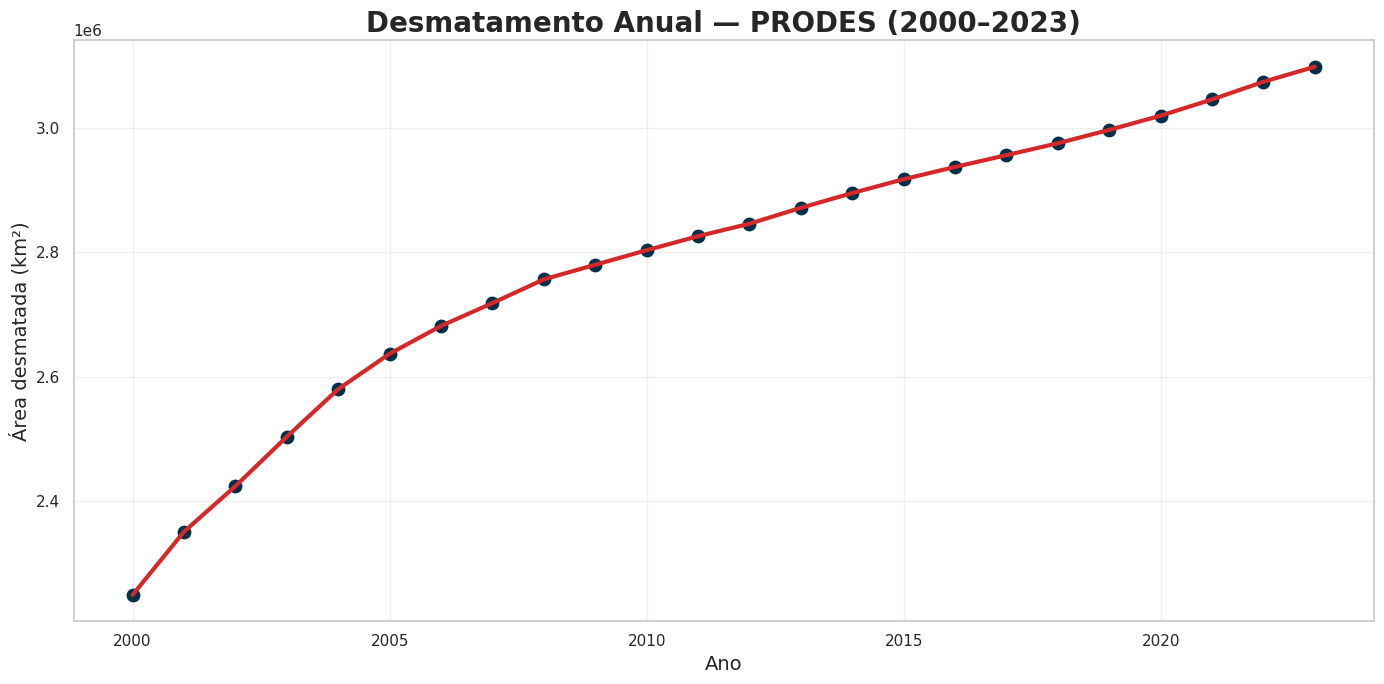

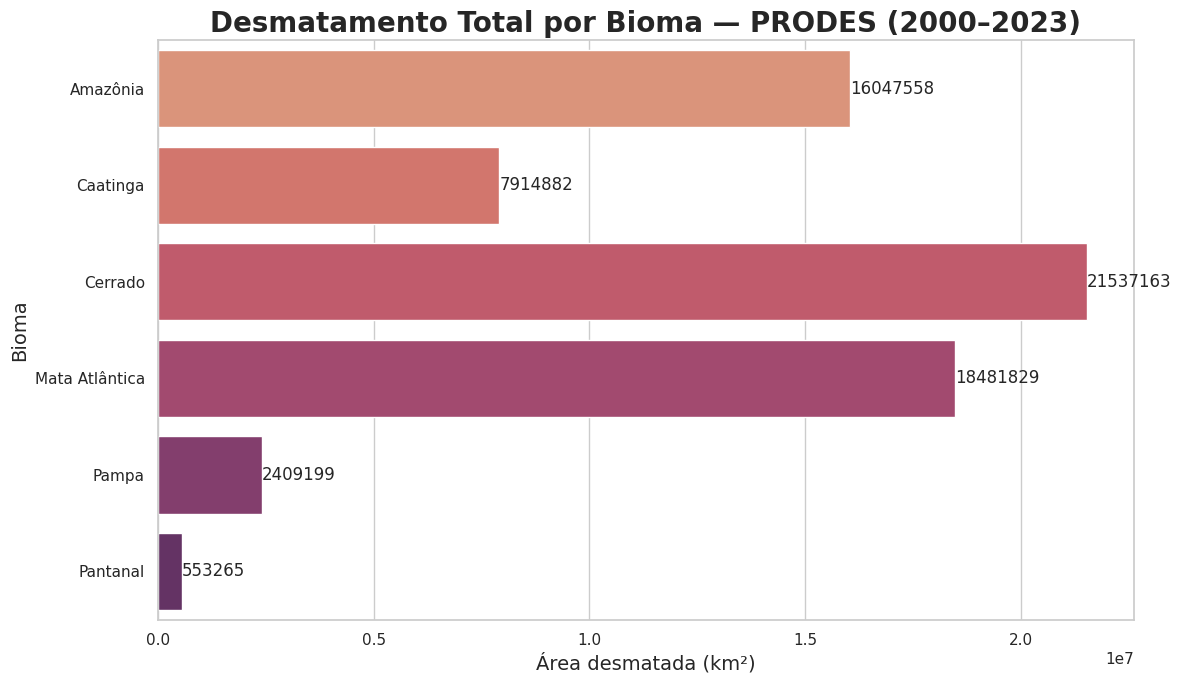

In [8]:
plt.figure(figsize=(14,7))
sns.lineplot(data=anual, x='ano', y='desmatado', linewidth=3, color="#D62828")
plt.scatter(anual['ano'], anual['desmatado'], color="#003049", s=80)

plt.title("Desmatamento Anual — PRODES (2000–2023)", fontsize=20, weight='bold')
plt.xlabel("Ano", fontsize=14)
plt.ylabel("Área desmatada (km²)", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quebra de linhaentre os gráficos
plt.figure(figsize=(0.1, 0.1))
plt.axis('off')
plt.show()

plt.figure(figsize=(12,7))
sns.barplot(data=bioma, y='bioma', x='desmatado', hue='bioma', palette="flare", legend=False)

plt.title("Desmatamento Total por Bioma — PRODES (2000–2023)", fontsize=20, weight='bold')
plt.xlabel("Área desmatada (km²)", fontsize=14)
plt.ylabel("Bioma", fontsize=14)

for index, value in enumerate(bioma['desmatado']):
    plt.text(value + 50, index, f"{value:.0f}", va='center')

plt.tight_layout()
plt.show()



## 💡 6. Insights Automáticos
Principais descobertas da análise.


In [9]:
maior_ano = anual.loc[anual['desmatado'].idxmax()]
menor_ano = anual.loc[anual['desmatado'].idxmin()]
maior_bioma = bioma.loc[bioma['desmatado'].idxmax()]

print(f"🔺 Ano com maior desmatamento: {maior_ano['ano']} ({maior_ano['desmatado']} km²)")
print(f"🔻 Ano com menor desmatamento: {menor_ano['ano']} ({menor_ano['desmatado']} km²)")
print(f"🌳 Bioma mais desmatado: {maior_bioma['bioma']} ({maior_bioma['desmatado']} km²)")


🔺 Ano com maior desmatamento: 2023.0 (3098130.2 km²)
🔻 Ano com menor desmatamento: 2000.0 (2249599.1 km²)
🌳 Bioma mais desmatado: Cerrado (21537163.0 km²)


## 🧭 7. Reflexão Ética e Impacto Social

O desmatamento afeta diretamente comunidades locais, biodiversidade,
recursos hídricos e o clima regional. Dados do PRODES permitem que
gestores públicos e privados tomem decisões baseadas em evidências,
planejem ações de fiscalização, identifiquem áreas críticas e avaliem
políticas ambientais.

Além disso, esses dados são fundamentais para orientar o planejamento
urbano, industrial e agropecuário. Ao identificar padrões de perda de
vegetação, é possível direcionar a expansão econômica e urbana para
áreas menos sensíveis, reduzindo prejuízos ambientais e sociais. Assim,
os dados do PRODES ajudam a equilibrar desenvolvimento econômico com
preservação dos biomas, permitindo estratégias de manejo sustentável,
zonas de proteção, corredores ecológicos e políticas de uso do solo mais
responsáveis.

Questões éticas incluem:
- Transparência no uso dos dados
- Responsabilidade na divulgação de informações
- LGPD quando cruzado com dados socioeconômicos
- Inclusão digital para acesso a alertas ambientais
- Uso responsável de IA para previsão e monitoramento
- Cuidado para que esses dados não sejam usados como ferramenta de
  manipulação política, especialmente em períodos eleitorais
- Prevenção contra fraudes, adulterações ou uso indevido dos dados para
  prejudicar populações locais ou favorecer grupos específicos

Do dado ao insight, o PRODES mostra como dados ambientais podem geram valor
humano, social e comercial. Quando usados de forma ética, permitem
proteger biomas, orientar políticas públicas e promover desenvolvimento
econômico sustentável.


## 🏁 8. Conclusão
Notebook concluído com sucesso.
